The plan is:
1. If there are 6 or more than 6 messages, then we will perform summarization 
2. For example: if we have 6 messages, then we will leave the last 2 recent messages and summarize the remaining (4 messages)
3. Summarization will trigger only when the state has 6 or more than 6 messages.

In [1]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class ChatState(MessagesState):
    summary: str

In [ ]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary: #if there are older summaries
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else: #summary for the 1st time
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [ ]:
def chat_node(state: ChatState):
    messages = []

    #check if there's any summary already present.
    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

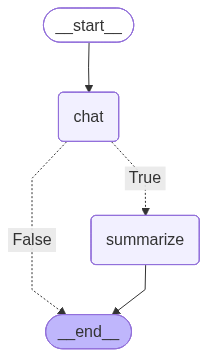

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='153638c5-1c76-4bbb-8d0f-094ef47bf9d1')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame


In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='153638c5-1c76-4bbb-8d0f-094ef47bf9d1'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that describes the physical properties and behaviors of matter and energy at the scale of atoms and subatomic particles. Here are some key concepts and principles:\n\n### 1. **Wave-Particle Duality**\nParticles, such as electrons and photons, exhibit both particle-like and wave-like behavior. This means they can show properties of discrete particles, as well as interference and diffraction patterns characteristic of waves.\n\n### 2. **Quantum Superposition**\nA quantum system can exist in multiple states simultaneously until it is measured. For example, in a famous thought experiment known as Schrödinger\'s cat, a cat in a box is both alive and dead until someone opens the box and observes it.\n\n### 3. **Quantum Entanglement**\nParticles 

In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='153638c5-1c76-4bbb-8d0f-094ef47bf9d1'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that describes the physical properties and behaviors of matter and energy at the scale of atoms and subatomic particles. Here are some key concepts and principles:\n\n### 1. **Wave-Particle Duality**\nParticles, such as electrons and photons, exhibit both particle-like and wave-like behavior. This means they can show properties of discrete particles, as well as interference and diffraction patterns characteristic of waves.\n\n### 2. **Quantum Superposition**\nA quantum system can exist in multiple states simultaneously until it is measured. For example, in a famous thought experiment known as Schrödinger\'s cat, a cat in a box is both alive and dead until someone opens the box and observes it.\n\n### 3. **Quantum Entanglement**\nParticles 

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='153638c5-1c76-4bbb-8d0f-094ef47bf9d1'), AIMessage(content='Quantum physics, also known as quantum mechanics or quantum theory, is a fundamental branch of physics that describes the physical properties and behaviors of matter and energy at the scale of atoms and subatomic particles. Here are some key concepts and principles:\n\n### 1. **Wave-Particle Duality**\nParticles, such as electrons and photons, exhibit both particle-like and wave-like behavior. This means they can show properties of discrete particles, as well as interference and diffraction patterns characteristic of waves.\n\n### 2. **Quantum Superposition**\nA quantum system can exist in multiple states simultaneously until it is measured. For example, in a famous thought experiment known as Schrödinger\'s cat, a cat in a box is both alive and dead until someone opens the box and observes it.\n\n### 3. **Quantum Entanglement**\nParticles 